In [135]:
!pip install numpy pandas gensim scikit-learn matplotlib scipy

In [136]:
import os
import re
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from gensim.models import KeyedVectors
import warnings
warnings.filterwarnings('ignore')

In [137]:
# чтение файла
data = []

with open('HW2_change.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

for line in lines:
    line = line.strip()
    if line and '\t' in line:
        verb, noun = line.split('\t')
        verb = verb.lower()
        noun = noun.lower()
        data.append((verb, noun))

df = pd.DataFrame(data, columns=['verb', 'noun'])
# df.to_csv('dataset.csv', index=False, encoding='utf-8')

In [138]:
# 1.

data = list(zip(df['verb'], df['noun']))
model = KeyedVectors.load_word2vec_format('model.bin', binary=True)

# если словарь модели не содержит искомых слов
filtered_data = []
removed_pairs = []

for verb, noun in data:
    if f'{verb}_VERB' in model and f'{noun}_NOUN' in model:
        filtered_data.append((f'{verb}_VERB', f'{noun}_NOUN'))
    else:
        removed_pairs.append((f'{verb}_VERB', f'{noun}_NOUN'))

# собираем вектора фраз
phrases = []
vectors = []

for verb, noun in filtered_data:
    # векторы из модели
    verb_vec = model[verb]
    noun_vec = model[noun]
    # аддитивная композиция
    phrase_vec = verb_vec + noun_vec
    phrases.append(f"{verb}_{noun}")
    vectors.append(phrase_vec)

vectors = np.array(vectors)
np.save('phrase_vectors.npy', vectors)

# список фраз
with open('phrases.txt', 'w', encoding='utf-8') as f:
    for phrase in phrases:
        f.write(phrase + '\n')

# итоговый датасет
df_filtered = pd.DataFrame(filtered_data, columns=['verb', 'noun'])
df_filtered.to_csv('dataset_filtered.csv', index=False, encoding='utf-8')


Порог устанавливает на каком уровне срезать дендрограмму, чем больше T, тем меньше кластеров. Значение 100 -- на самом деле просто методом подбора чтобы получились какие-то хоть сколько-то интерпретируемые кластеры...


Кластер 1 (размер: 36):
  1. изменить_VERB_йота_NOUN
  2. изменить_VERB_убеждение_NOUN
  3. изменить_VERB_поведение_NOUN

Кластер 2 (размер: 19):
  1. изменить_VERB_тактика_NOUN
  2. изменить_VERB_поза_NOUN
  3. изменить_VERB_траектория_NOUN

Кластер 3 (размер: 20):
  1. заменить_VERB_колесо_NOUN
  2. заменить_VERB_кран_NOUN
  3. заменить_VERB_машина_NOUN

Кластер 4 (размер: 28):
  1. заменить_VERB_повешение_NOUN
  2. заменить_VERB_наказание_NOUN
  3. заменить_VERB_казнь_NOUN

Кластер 5 (размер: 4):
  1. сменить_VERB_должность_NOUN
  2. заменить_VERB_должность_NOUN
  3. заменить_VERB_пост_NOUN

Кластер 6 (размер: 50):
  1. сменить_VERB_наволочка_NOUN
  2. сменить_VERB_пиджак_NOUN
  3. сменить_VERB_прическа_NOUN

Кластер 7 (размер: 29):
  1. поменять_VERB_детройт_NOUN
  2. поменять_VERB_шило_NOUN
  3. поменять_VERB_бакс_NOUN

Кластер 8 (размер: 4):
  1. поменять_VERB_название_NOUN
  2. сменить_VERB_название_NOUN
  3. заменить_VERB_название_NOUN

Кластер 9 (размер: 8):
  1. сменить_VERB

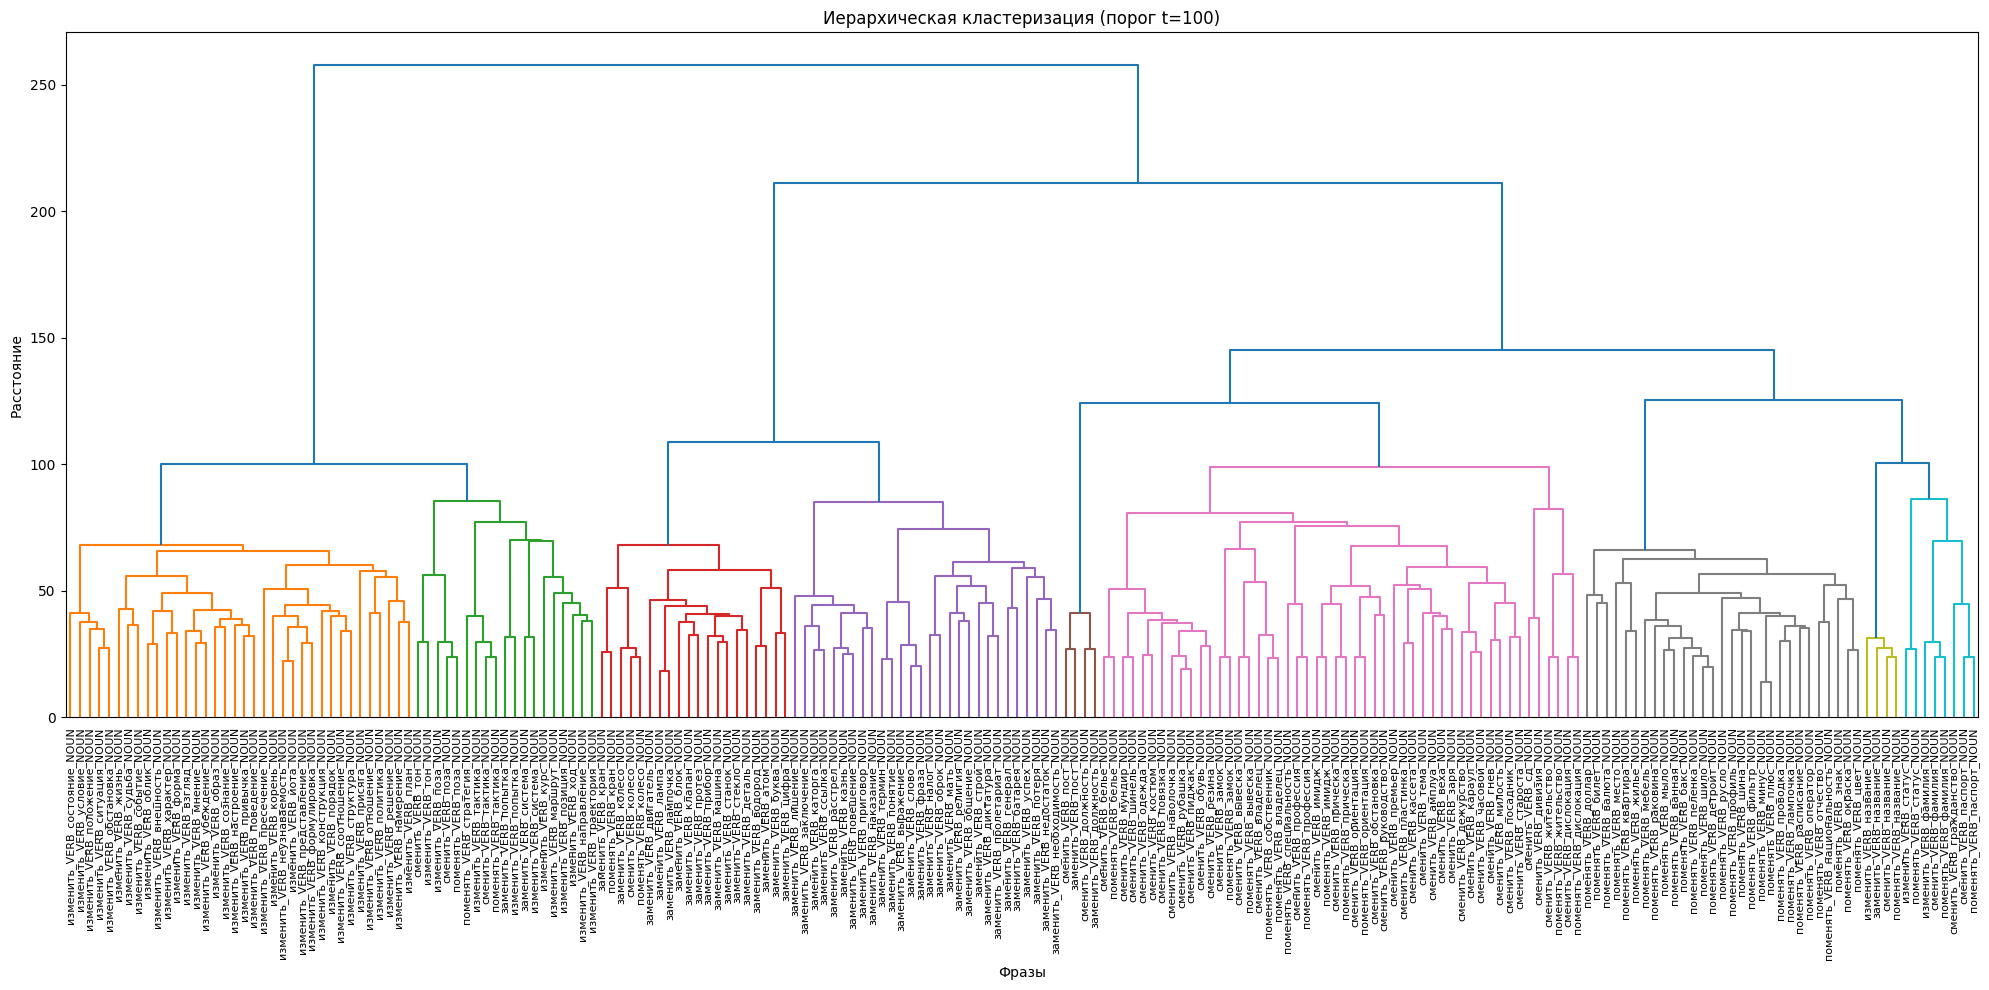

In [139]:
#2.
T = 100  # порог для определения количества кластеров

# загрузка заново
vectors = np.load('phrase_vectors.npy')
with open('phrases.txt', 'r', encoding='utf-8') as f:
    phrases = [line.strip() for line in f.readlines()]


linkage_matrix = linkage(vectors, method='ward')
clusters = fcluster(linkage_matrix, t=T, criterion='distance')

unique_clusters = np.unique(clusters)
cluster_info = {}

for cluster_id in unique_clusters:
    cluster_indices = np.where(clusters == cluster_id)[0]
    cluster_size = len(cluster_indices)

    if cluster_size <= 2:
        continue

    cluster_vectors = vectors[cluster_indices]
    cluster_phrases = [phrases[i] for i in cluster_indices]

    center = np.mean(cluster_vectors, axis=0)

    # косинусная близость к центру
    similarities = cosine_similarity([center], cluster_vectors)[0]
    nearest_indices = np.argsort(similarities)[-3:][::-1]
    nearest_phrases = [cluster_phrases[i] for i in nearest_indices]

    cluster_info[cluster_id] = {
        'size': cluster_size,
        'center': center,
        'nearest': nearest_phrases,
        'all_phrases': cluster_phrases
    }

for cluster_id, info in sorted(cluster_info.items()):
  if info['size'] > 2:
      print(f"\nКластер {cluster_id} (размер: {info['size']}):")
      for i, phrase in enumerate(info['nearest'], 1):
          print(f"  {i}. {phrase}")


unique_clusters = np.unique(clusters)
print(f"всего {len(unique_clusters)} кластеров")

# дендрограмма
plt.figure(figsize=(20, 10))
dendrogram(linkage_matrix, labels=phrases, leaf_rotation=90, leaf_font_size=8, color_threshold=100)
plt.title(f'Иерархическая кластеризация (порог t={T})')
plt.xlabel('Фразы')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()



Кластер 1 (размер: 4):
  1. сменить_VERB_должность_NOUN
  2. заменить_VERB_должность_NOUN
  3. заменить_VERB_пост_NOUN

Кластер 2 (размер: 10):
  1. изменить_VERB_тактика_NOUN
  2. изменить_VERB_ход_NOUN
  3. изменить_VERB_траектория_NOUN

Кластер 3 (размер: 49):
  1. поменять_VERB_детройт_NOUN
  2. поменять_VERB_шило_NOUN
  3. поменять_VERB_бакс_NOUN

Кластер 4 (размер: 24):
  1. заменить_VERB_повешение_NOUN
  2. заменить_VERB_наказание_NOUN
  3. заменить_VERB_казнь_NOUN

Кластер 5 (размер: 23):
  1. заменить_VERB_машина_NOUN
  2. заменить_VERB_прибор_NOUN
  3. заменить_VERB_протез_NOUN

Кластер 6 (размер: 10):
  1. изменить_VERB_условие_NOUN
  2. изменить_VERB_положение_NOUN
  3. изменить_VERB_ситуация_NOUN

Кластер 7 (размер: 45):
  1. сменить_VERB_наволочка_NOUN
  2. сменить_VERB_пиджак_NOUN
  3. сменить_VERB_часовой_NOUN

Кластер 8 (размер: 4):
  1. поменять_VERB_название_NOUN
  2. сменить_VERB_название_NOUN
  3. заменить_VERB_название_NOUN

Кластер 9 (размер: 29):
  1. изменить_

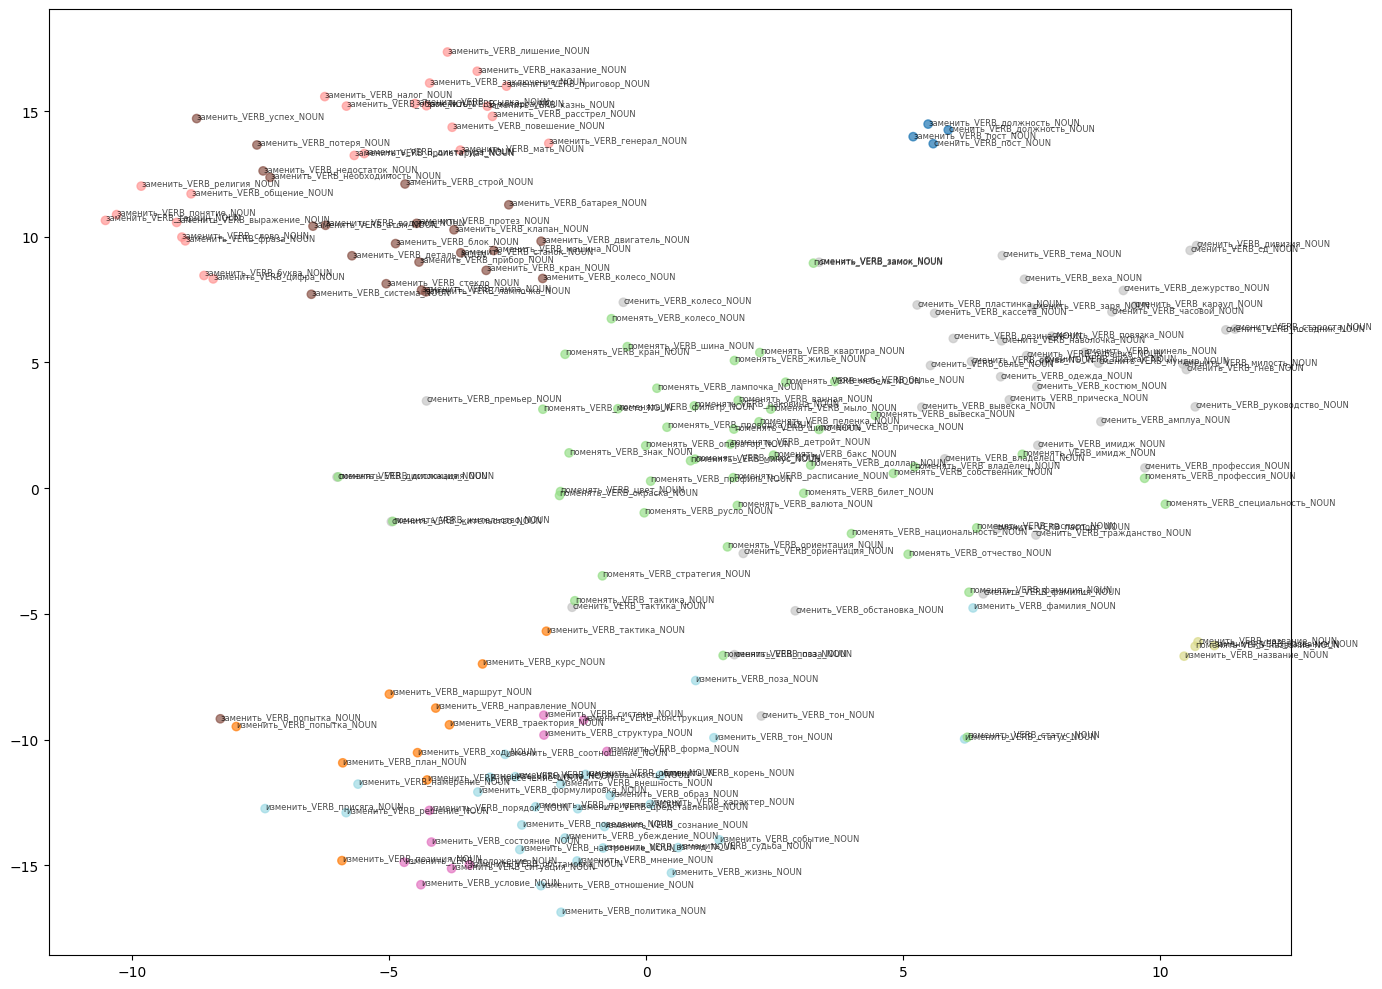

In [141]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# параметры
N_CLUSTERS = 9  # количество кластеров

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vectors)

unique_clusters = np.unique(clusters)
cluster_info = {}

for cluster_id in unique_clusters:
    cluster_indices = np.where(clusters == cluster_id)[0]
    cluster_size = len(cluster_indices)

    if cluster_size <= 2:
        continue

    cluster_vectors = vectors[cluster_indices]
    cluster_phrases = [phrases[i] for i in cluster_indices]

    # центр из KMeans
    center = kmeans.cluster_centers_[cluster_id]

    # косинусная близость к центру
    similarities = cosine_similarity([center], cluster_vectors)[0]
    nearest_indices = np.argsort(similarities)[-3:][::-1]
    nearest_phrases = [cluster_phrases[i] for i in nearest_indices]

    cluster_info[cluster_id] = {
        'size': cluster_size,
        'center': center,
        'nearest': nearest_phrases,
        'all_phrases': cluster_phrases
    }


for cluster_id, info in sorted(cluster_info.items()):
  if info['size'] > 2:
      print(f"\nКластер {cluster_id+1} (размер: {info['size']}):")
      for i, phrase in enumerate(info['nearest'], 1):
          print(f"  {i}. {phrase}")

def visualize_clusters(vectors, cluster_labels, phrases):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)

    plt.figure(figsize=(14, 10))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
                         c=cluster_labels, cmap='tab20', alpha=0.7)

    # подписи точек
    for i, phrase in enumerate(phrases):
        plt.annotate(phrase, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=6, alpha=0.7)

    plt.tight_layout()
    plt.show()

visualize_clusters(vectors, clusters, phrases)

В целом и классификация и иерархической кластеризацией, и с помощью KNN дают похожие кластеры. Для сравнимости также взял 9 кластеров.

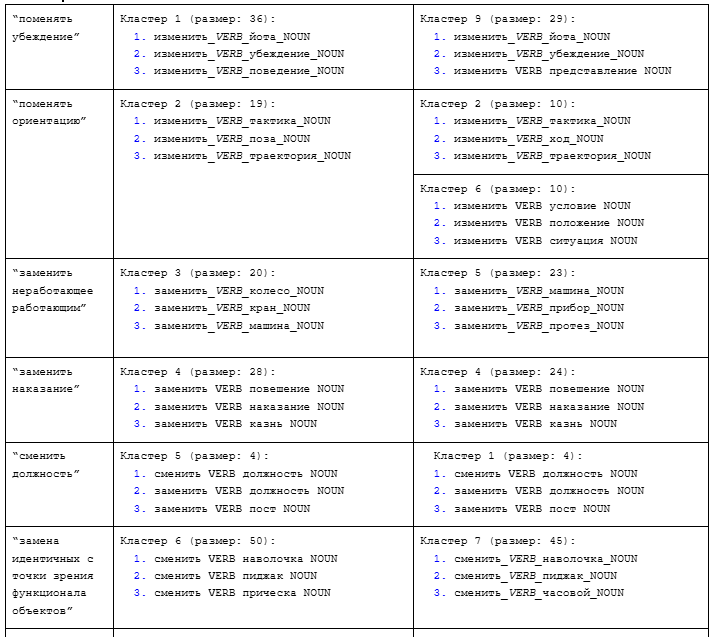
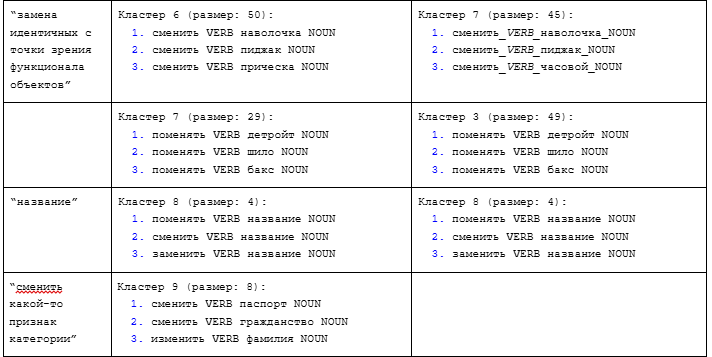

Наблюдения:
* Семантика существительного определяет группу (=значение всего словосочетания) сильнее, чем глагол.
* Загадочный класс поменять детройт / шило / бакс -- а в KNN еще и очень большой -- 49 сочетаний из 200. Похож на мусорный (?) надо бы посмотреть больше чем три...

## Другой датасет

4 глагола: прятать (50 штук), скрывать (50 штук),утаивать (11 штук, максимум) беречь (50 штук).


Из поиска коллокаций НКРЯ: запрос "глагол + имя сущ в вин. падеже", топ-50 по частотте совместнй встречаемости, просто выкачаны и перетащены ручками.

In [142]:
df = pd.read_csv('/content/ruscorpora_content.xlsx - Sheet1.csv', header=None, names=['verb', 'noun'])
df

,verb,noun
0,прятать,глаз
1,прятать,лицо
2,прятать,голова
3,прятать,рука
4,прятать,деньги
...,...,...
156,беречь,ночь
157,беречь,тайна
158,беречь,минута
159,беречь,снаряд


In [144]:
# 1.

data = list(zip(df['verb'], df['noun']))
model = KeyedVectors.load_word2vec_format('model.bin', binary=True)

# если словарь модели не содержит искомых слов
filtered_data = []
removed_pairs = []

for verb, noun in data:
    if f'{verb}_VERB' in model and f'{noun}_NOUN' in model:
        filtered_data.append((f'{verb}_VERB', f'{noun}_NOUN'))
    else:
        removed_pairs.append((f'{verb}_VERB', f'{noun}_NOUN'))

# собираем вектора фраз
phrases = []
vectors = []

for verb, noun in filtered_data:
    # векторы из модели
    verb_vec = model[verb]
    noun_vec = model[noun]
    # аддитивная композиция
    phrase_vec = verb_vec + noun_vec
    phrases.append(f"{verb}_{noun}")
    vectors.append(phrase_vec)

vectors = np.array(vectors)
np.save('phrase_vectors.npy', vectors)

# список фраз
with open('phrases.txt', 'w', encoding='utf-8') as f:
    for phrase in phrases:
        f.write(phrase + '\n')

# итоговый датасет
df_filtered = pd.DataFrame(filtered_data, columns=['verb', 'noun'])
df_filtered.to_csv('dataset_filtered.csv', index=False, encoding='utf-8')



Кластер 1 (размер: 3):
  1. прятать_VERB_год_NOUN
  2. беречь_VERB_год_NOUN
  3. скрывать_VERB_год_NOUN

Кластер 2 (размер: 33):
  1. скрывать_VERB_правда_NOUN
  2. скрывать_VERB_факт_NOUN
  3. скрывать_VERB_чувство_NOUN

Кластер 3 (размер: 21):
  1. прятать_VERB_бумажка_NOUN
  2. прятать_VERB_карман_NOUN
  3. прятать_VERB_бутылка_NOUN

Кластер 4 (размер: 19):
  1. прятать_VERB_глаз_NOUN
  2. прятать_VERB_рука_NOUN
  3. скрывать_VERB_рука_NOUN

Кластер 5 (размер: 12):
  1. прятать_VERB_письмо_NOUN
  2. беречь_VERB_письмо_NOUN
  3. прятать_VERB_слово_NOUN

Кластер 6 (размер: 19):
  1. беречь_VERB_деньги_NOUN
  2. беречь_VERB_хлеб_NOUN
  3. прятать_VERB_деньги_NOUN

Кластер 7 (размер: 27):
  1. беречь_VERB_мать_NOUN
  2. беречь_VERB_любовь_NOUN
  3. беречь_VERB_сердце_NOUN

Кластер 8 (размер: 12):
  1. прятать_VERB_день_NOUN
  2. скрывать_VERB_день_NOUN
  3. прятать_VERB_раз_NOUN

Кластер 9 (размер: 15):
  1. прятать_VERB_время_NOUN
  2. скрывать_VERB_время_NOUN
  3. прятать_VERB_челове

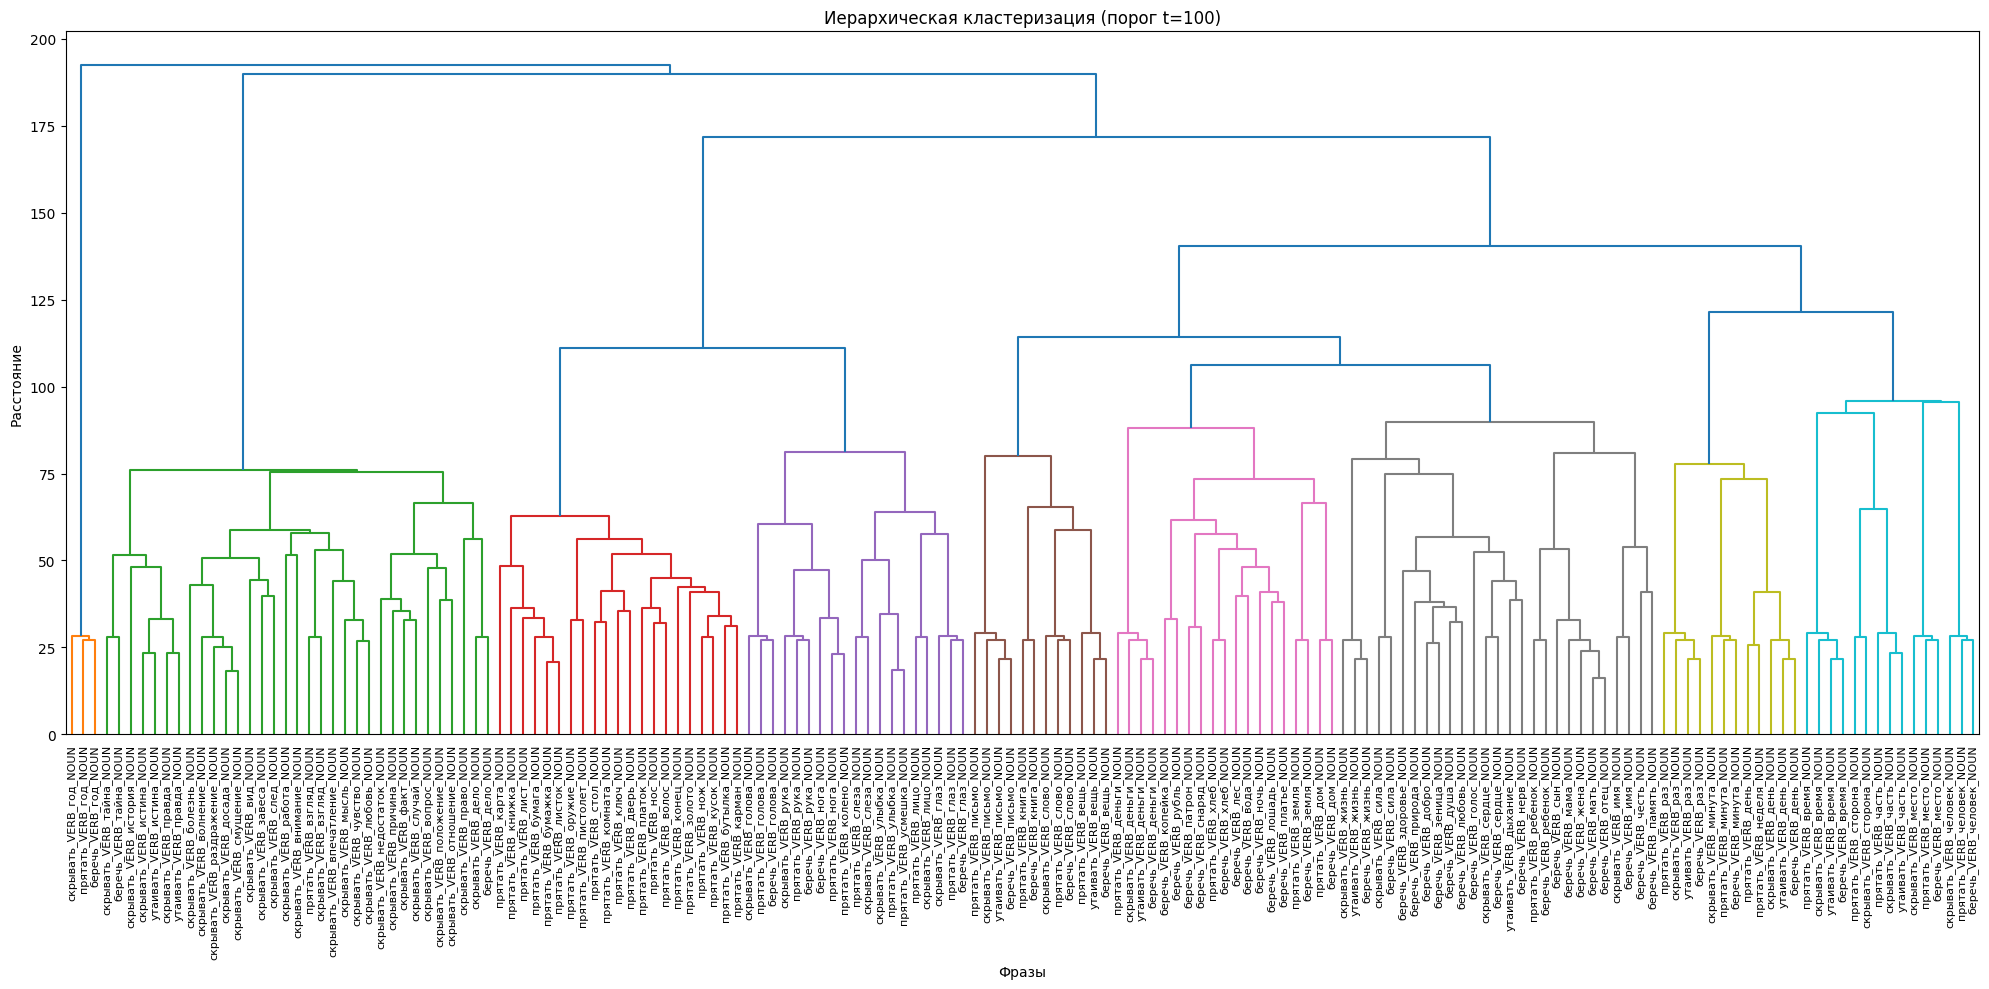

In [145]:
#2.
T = 100  # порог для определения количества кластеров

# загрузка заново
vectors = np.load('phrase_vectors.npy')
with open('phrases.txt', 'r', encoding='utf-8') as f:
    phrases = [line.strip() for line in f.readlines()]


linkage_matrix = linkage(vectors, method='ward')
clusters = fcluster(linkage_matrix, t=T, criterion='distance')

unique_clusters = np.unique(clusters)
cluster_info = {}

for cluster_id in unique_clusters:
    cluster_indices = np.where(clusters == cluster_id)[0]
    cluster_size = len(cluster_indices)

    if cluster_size <= 2:
        continue

    cluster_vectors = vectors[cluster_indices]
    cluster_phrases = [phrases[i] for i in cluster_indices]

    center = np.mean(cluster_vectors, axis=0)

    # косинусная близость к центру
    similarities = cosine_similarity([center], cluster_vectors)[0]
    nearest_indices = np.argsort(similarities)[-3:][::-1]
    nearest_phrases = [cluster_phrases[i] for i in nearest_indices]

    cluster_info[cluster_id] = {
        'size': cluster_size,
        'center': center,
        'nearest': nearest_phrases,
        'all_phrases': cluster_phrases
    }

for cluster_id, info in sorted(cluster_info.items()):
  if info['size'] > 2:
      print(f"\nКластер {cluster_id} (размер: {info['size']}):")
      for i, phrase in enumerate(info['nearest'], 1):
          print(f"  {i}. {phrase}")


unique_clusters = np.unique(clusters)
print(f"всего {len(unique_clusters)} кластеров")

# дендрограмма
plt.figure(figsize=(20, 10))
dendrogram(linkage_matrix, labels=phrases, leaf_rotation=90, leaf_font_size=8, color_threshold=100)
plt.title(f'Иерархическая кластеризация (порог t={T})')
plt.xlabel('Фразы')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()



Кластер 1 (размер: 3):
  1. прятать_VERB_место_NOUN
  2. беречь_VERB_место_NOUN
  3. скрывать_VERB_место_NOUN

Кластер 2 (размер: 6):
  1. скрывать_VERB_деньги_NOUN
  2. утаивать_VERB_деньги_NOUN
  3. беречь_VERB_деньги_NOUN

Кластер 3 (размер: 40):
  1. прятать_VERB_карман_NOUN
  2. прятать_VERB_бумажка_NOUN
  3. прятать_VERB_нож_NOUN

Кластер 4 (размер: 12):
  1. прятать_VERB_день_NOUN
  2. скрывать_VERB_день_NOUN
  3. прятать_VERB_раз_NOUN

Кластер 5 (размер: 8):
  1. беречь_VERB_хлеб_NOUN
  2. беречь_VERB_земля_NOUN
  3. прятать_VERB_хлеб_NOUN

Кластер 6 (размер: 4):
  1. утаивать_VERB_время_NOUN
  2. скрывать_VERB_время_NOUN
  3. беречь_VERB_время_NOUN

Кластер 7 (размер: 3):
  1. прятать_VERB_год_NOUN
  2. беречь_VERB_год_NOUN
  3. скрывать_VERB_год_NOUN

Кластер 8 (размер: 45):
  1. скрывать_VERB_чувство_NOUN
  2. скрывать_VERB_правда_NOUN
  3. скрывать_VERB_досада_NOUN

Кластер 9 (размер: 40):
  1. беречь_VERB_мать_NOUN
  2. беречь_VERB_сердце_NOUN
  3. беречь_VERB_добро_NOUN


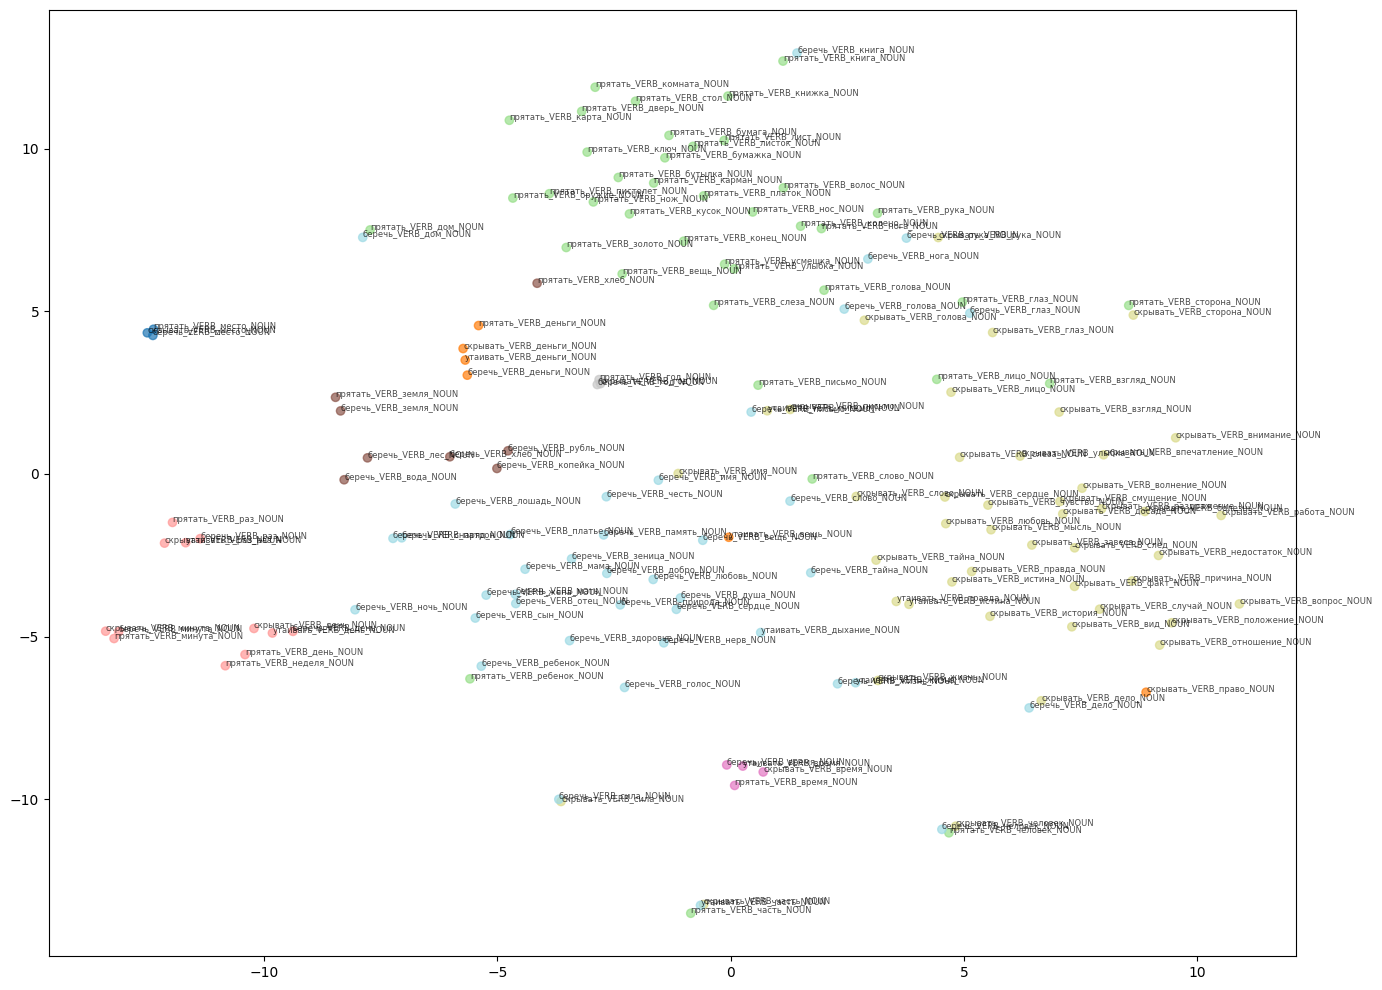

In [146]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Параметры
N_CLUSTERS = 9  # количество кластеров

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vectors)

unique_clusters = np.unique(clusters)
cluster_info = {}

for cluster_id in unique_clusters:
    cluster_indices = np.where(clusters == cluster_id)[0]
    cluster_size = len(cluster_indices)

    if cluster_size <= 2:
        continue

    cluster_vectors = vectors[cluster_indices]
    cluster_phrases = [phrases[i] for i in cluster_indices]

    # центр из KMeans
    center = kmeans.cluster_centers_[cluster_id]

    # косинусная близость к центру
    similarities = cosine_similarity([center], cluster_vectors)[0]
    nearest_indices = np.argsort(similarities)[-3:][::-1]
    nearest_phrases = [cluster_phrases[i] for i in nearest_indices]

    cluster_info[cluster_id] = {
        'size': cluster_size,
        'center': center,
        'nearest': nearest_phrases,
        'all_phrases': cluster_phrases
    }


for cluster_id, info in sorted(cluster_info.items()):
  if info['size'] > 2:
      print(f"\nКластер {cluster_id+1} (размер: {info['size']}):")
      for i, phrase in enumerate(info['nearest'], 1):
          print(f"  {i}. {phrase}")

def visualize_clusters(vectors, cluster_labels, phrases):
    # Уменьшаем размерность
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)

    # Рисуем
    plt.figure(figsize=(14, 10))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
                         c=cluster_labels, cmap='tab20', alpha=0.7)

    # Добавляем подписи для точек
    for i, phrase in enumerate(phrases):
        plt.annotate(phrase, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=6, alpha=0.7)

    plt.tight_layout()
    plt.show()

visualize_clusters(vectors, clusters, phrases)

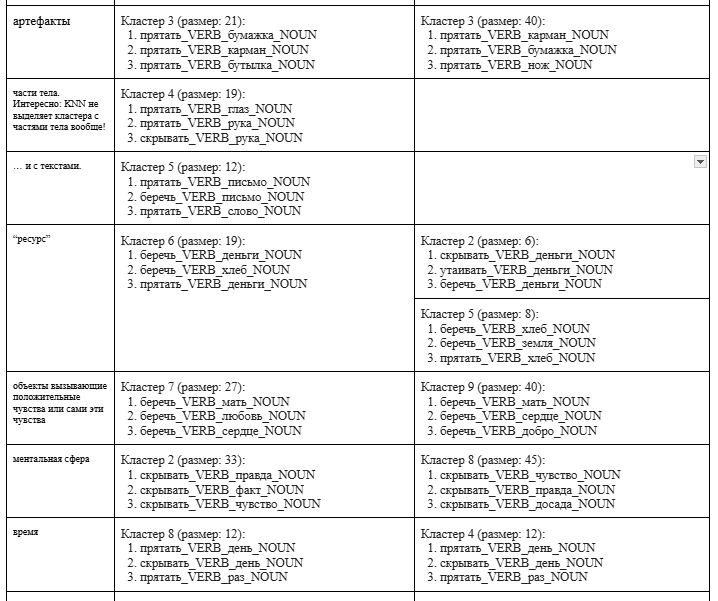

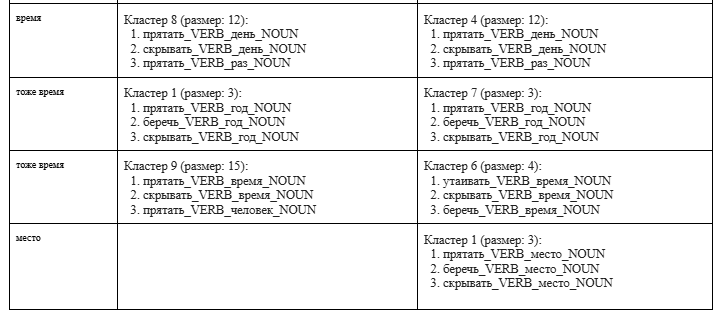

Кластеризация почти только по именам-коллокатам -- по данным кажется, что выбор глагола зависит от имени.  

Кластеры менее совпадающие, чем в предыдущем задании, и есть несколько неинтуитивно разделенных групп. Это кластеры с именами, означающими временные промежутки.
